# Experiment 5: Decision Tree and Random Forest — A Comparative Classification Study

**Course:** ICS1512 — Machine Learning Algorithms Laboratory
**Student:** Nathaniel Christian
**Register Number:** 3122247001037
**Faculty:** Dr. Poreddy Ajay Kumar Reddy
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC) Dataset

## 2. Objective

- To implement a Decision Tree classifier for breast cancer diagnosis.
- To extend the Decision Tree into a Random Forest ensemble model.
- To study the impact of hyperparameters on overfitting and generalization.
- To select optimal hyperparameters using 5-Fold Cross-Validation.
- To compare the performance of a single-tree model against an ensemble-tree model.

## 3. Problem Statement

Given 30 numerical features computed from digitized images of fine needle aspirates (FNA) of breast
masses, the task is to build a binary classifier that predicts whether a tumor is **Malignant (M)** or
**Benign (B)**. A Decision Tree classifier and a Random Forest ensemble classifier are trained, tuned
via 5-fold cross-validation, and compared on held-out test data using standard classification metrics
(Accuracy, Precision, Recall, F1-score, ROC-AUC).

In [1]:
# ============================================================
# 4. Import Required Libraries
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import itertools
import time

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)

import sklearn
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)

# ------------------------------------------------------------
# Global plotting configuration (Professor's requirement):
# Times New Roman, 15pt text, bold 15pt axis labels, 15pt legends
# NOTE: "Times New Roman" itself is a proprietary Microsoft font not present
# on this Linux machine. "Liberation Serif" is used as the metric-compatible,
# visually-identical open-source substitute (same glyph widths as Times New
# Roman), so that all figures keep a Times-like serif appearance.
# ------------------------------------------------------------
plt.rcParams['font.family'] = 'Liberation Serif'
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 15

RANDOM_STATE = 42
FIG_DIR = "figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    """Reusable helper to export a figure as EPS at 600 DPI (professor's requirement)."""
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    print("Saved:", path)
    return path

pandas: 3.0.2
numpy: 2.4.4
scikit-learn: 1.8.0
matplotlib: 3.10.8


## 5. Dataset Loading

Dataset: **Wisconsin Diagnostic Breast Cancer (WDBC)** dataset
(`datasets/breastCancer/wdbc.data`, documented in `datasets/breastCancer/wdbc.names`).

Per `wdbc.names`: 569 instances, 32 attributes total = 1 ID column + 1 diagnosis (target) column +
30 real-valued numerical features (mean, standard-error, and "worst" of 10 base cell-nucleus
measurements). There is no header row in the raw `.data` file, so column names are assigned manually
based on the attribute description in `wdbc.names`.

In [2]:
# ============================================================
# 5. Dataset Loading
# ============================================================
DATA_PATH = "../datasets/breastCancer/wdbc.data"
NAMES_PATH = "../datasets/breastCancer/wdbc.names"

# Column names built from wdbc.names attribute description:
# ID, diagnosis, then 10 base measurements x 3 statistics (mean, se, worst)
_base_features = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"
]
_stat_suffixes = ["mean", "se", "worst"]
COLUMN_NAMES = ["id", "diagnosis"] + [f"{feat}_{stat}" for stat in _stat_suffixes for feat in _base_features]

print("Total columns expected:", len(COLUMN_NAMES))

df = pd.read_csv(DATA_PATH, header=None, names=COLUMN_NAMES)
print("Dataset loaded. Shape:", df.shape)
df.head()

Total columns expected: 32
Dataset loaded. Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 6. Dataset Description

Basic structural inspection of the dataset before any preprocessing.

In [3]:
# ============================================================
# 6. Dataset Description
# ============================================================
print("Shape (rows, columns):", df.shape)
print()
print("Data types:")
print(df.dtypes.value_counts())
print()
print("Column list:")
print(list(df.columns))
print()
print("Class distribution (raw):")
print(df['diagnosis'].value_counts())
print()
df.describe().T

Shape (rows, columns): (569, 32)

Data types:
float64    30
int64       1
str         1
Name: count, dtype: int64

Column list:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Class distribution (raw):
diagnosis
B    357
M    212
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave_points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


## 7. Data Preprocessing

Steps performed:
1. Check for missing values.
2. Check for duplicate rows.
3. Encode the target label (`diagnosis`) using `LabelEncoder`.
4. Drop the `id` column (identifier only, not predictive) and the raw `diagnosis` column from the
   feature matrix.
5. Build the feature matrix `X` (30 numerical features) and target vector `y`.

In [4]:
# ============================================================
# 7. Data Preprocessing
# ============================================================

# 7.1 Missing values
print("Total missing values:", df.isnull().sum().sum())
print(df.isnull().sum()[df.isnull().sum() > 0])

# 7.2 Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# 7.3 Encode target labels
label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['diagnosis'])
print("\nLabel encoding mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# 7.4 Build X (exclude id, diagnosis, target) and y
feature_columns = [c for c in df.columns if c not in ("id", "diagnosis", "target")]
print("\nNumber of predictive features:", len(feature_columns))
assert len(feature_columns) == 30, "Expected exactly 30 predictive features!"

X = df[feature_columns].copy()
y = df['target'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget class balance:")
print(y.value_counts().rename({0: 'Benign (0)', 1: 'Malignant (1)'}))

Total missing values: 0
Series([], dtype: int64)

Duplicate rows: 0

Label encoding mapping: {'B': np.int64(0), 'M': np.int64(1)}

Number of predictive features: 30
X shape: (569, 30)
y shape: (569,)

Target class balance:
target
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64


## 8. Exploratory Data Analysis

### 8.1 Dataset Overview

In [5]:
# ============================================================
# 8.1 Dataset Overview — Statistical Summary
# ============================================================
X.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
radius_mean,14.127292,3.524049,6.981000,28.11000
texture_mean,19.289649,4.301036,9.710000,39.28000
perimeter_mean,91.969033,24.298981,43.790000,188.50000
area_mean,654.889104,351.914129,143.500000,2501.00000
smoothness_mean,0.096360,0.014064,0.052630,0.16340
compactness_mean,0.104341,0.052813,0.019380,0.34540
concavity_mean,0.088799,0.079720,0.000000,0.42680
concave_points_mean,0.048919,0.038803,0.000000,0.20120
symmetry_mean,0.181162,0.027414,0.106000,0.30400
fractal_dimension_mean,0.062798,0.007060,0.049960,0.09744


### 8.2 Class Distribution

Saved: figures/fig1_class_distribution.eps


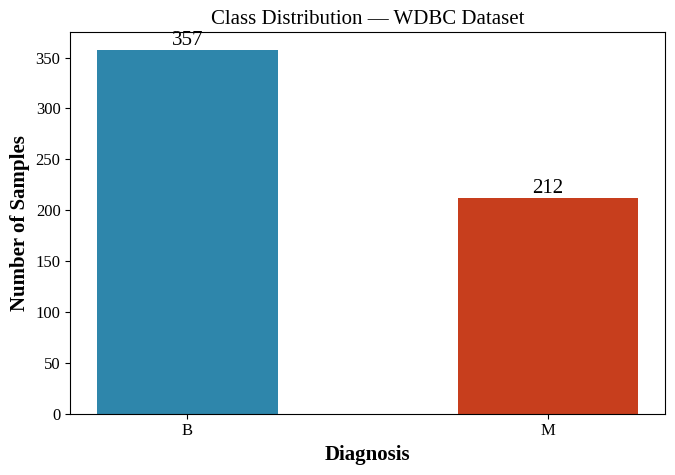

Benign : Malignant ratio = 1.68 : 1


In [6]:
# ============================================================
# 8.2 Class Distribution (standalone required figure)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['diagnosis'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2E86AB', '#C73E1D'], width=0.5)
ax.set_xlabel("Diagnosis", fontweight='bold')
ax.set_ylabel("Number of Samples", fontweight='bold')
ax.set_title("Class Distribution — WDBC Dataset")
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontsize=15)
plt.tight_layout()
save_fig(fig, "fig1_class_distribution.eps")
plt.show()

print("Benign : Malignant ratio =", round(counts['B']/counts['M'], 2), ": 1")

### 8.3 Correlation Analysis

Saved: figures/fig2_correlation_matrix.eps


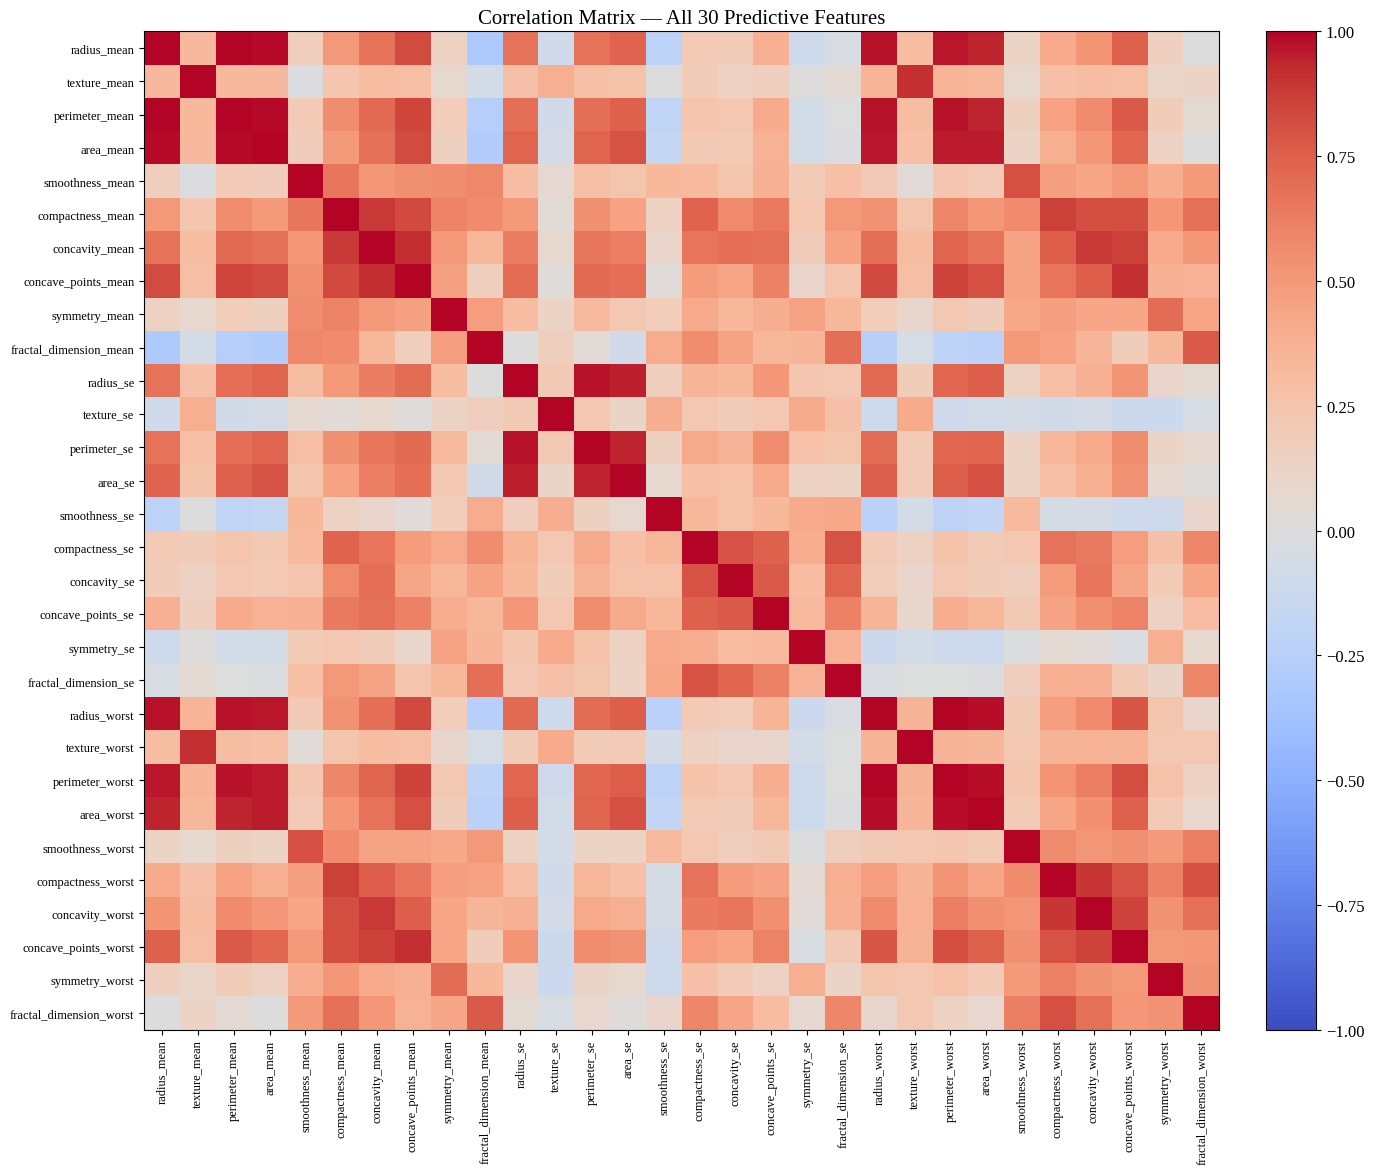

Top 10 features most correlated with target (diagnosis):
concave_points_worst    0.793566
perimeter_worst         0.782914
concave_points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: target, dtype: float64


In [7]:
# ============================================================
# 8.3 Correlation Analysis (standalone required figure)
# ============================================================
corr_matrix = X.corr()

# NOTE: pcolormesh (vector quads) is used instead of imshow to keep the EPS
# file size reasonable at 600 DPI (imshow rasterizes the whole image at the
# target DPI regardless of the underlying 30x30 data resolution).
fig, ax = plt.subplots(figsize=(14, 12))
n = len(feature_columns)
mesh = ax.pcolormesh(corr_matrix.values[::-1], cmap='coolwarm', vmin=-1, vmax=1, edgecolors='none')
ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)
ax.set_xticklabels(feature_columns, rotation=90, fontsize=9)
ax.set_yticklabels(feature_columns[::-1], fontsize=9)
ax.set_xlim(0, n); ax.set_ylim(0, n)
cbar = plt.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)
ax.set_title("Correlation Matrix — All 30 Predictive Features")
plt.tight_layout()
save_fig(fig, "fig2_correlation_matrix.eps")
plt.show()

# Features most correlated with the target
target_corr = X.copy()
target_corr['target'] = y
top_corr = target_corr.corr()['target'].drop('target').sort_values(key=abs, ascending=False)
print("Top 10 features most correlated with target (diagnosis):")
print(top_corr.head(10))

### 8.4 Consolidated 12-Plot EDA

Per the professor's requirement, a single reusable function `generate_eda_summary()` produces
**one consolidated figure containing exactly 12 subplots**, giving a complete diagnostic overview
of the dataset (class balance, correlation structure, feature distributions, and inter-feature
relationships).

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/fig3_eda_12panel.eps


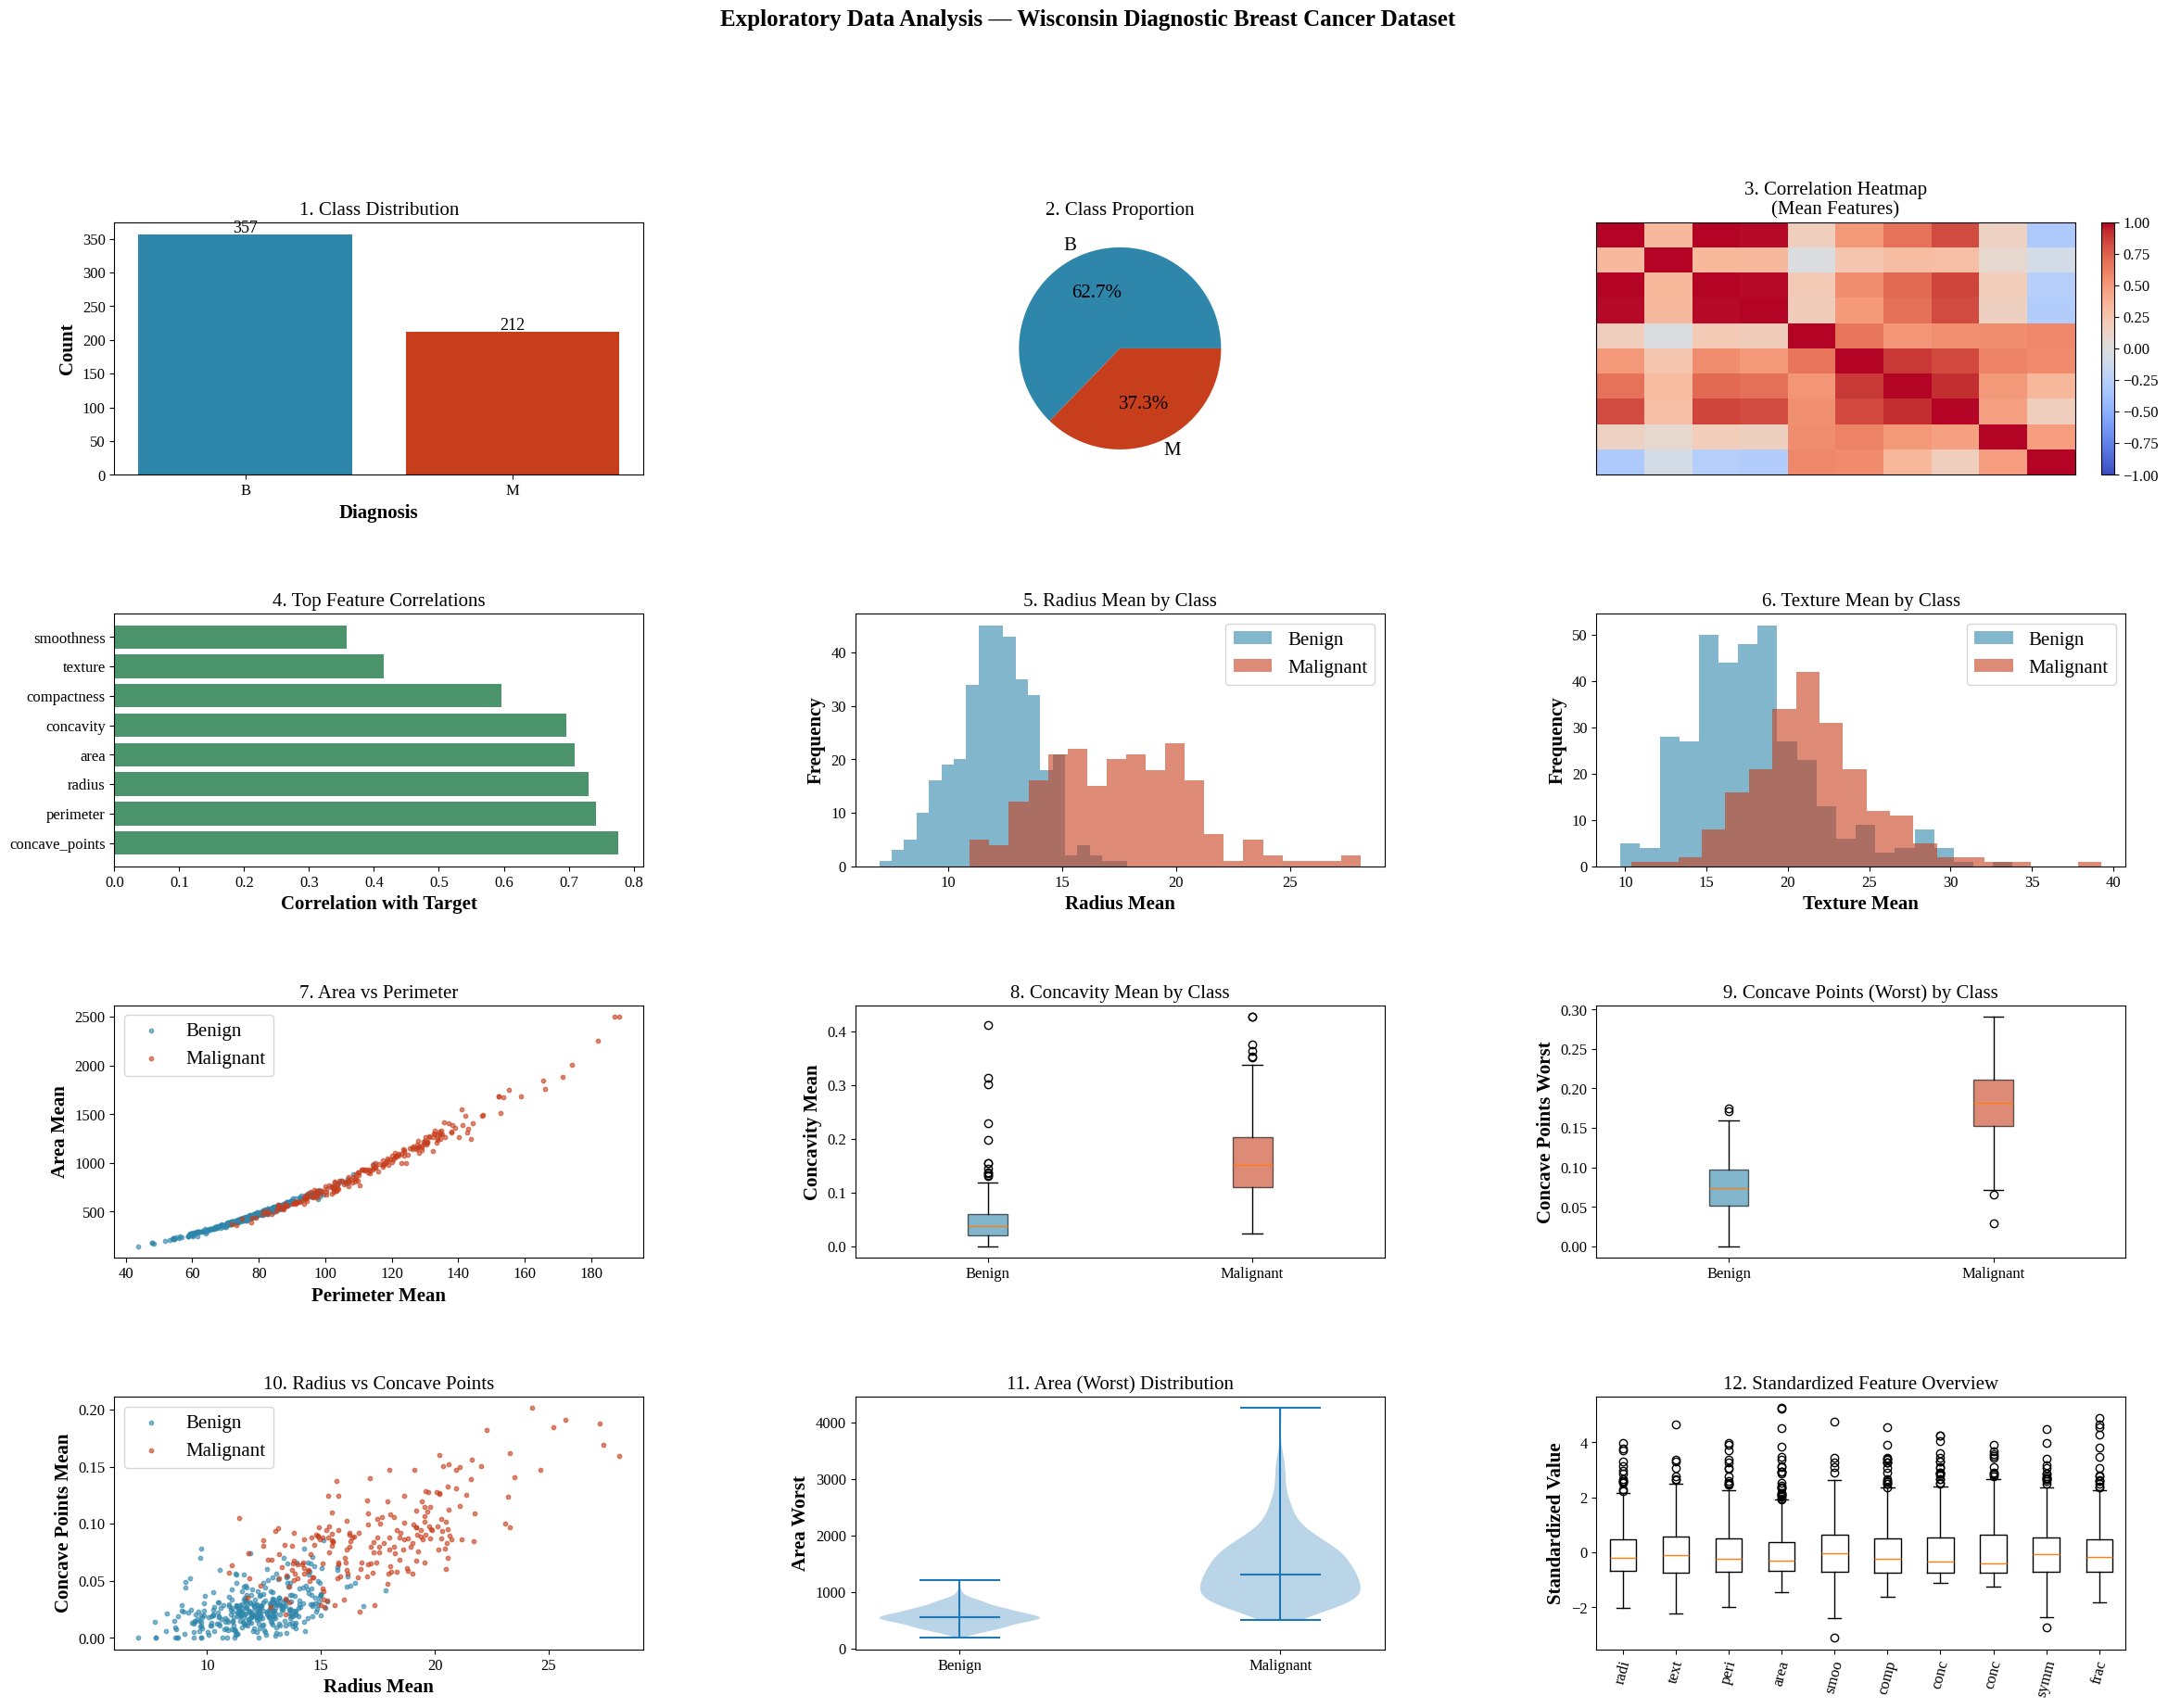

In [8]:
# ============================================================
# 8.4 Reusable Function A: Consolidated 12-Subplot EDA
# ============================================================
def generate_eda_summary(dataframe, mean_feature_cols, save_path_name=None):
    """
    Reusable EDA function (Professor's Requirement A).
    Generates ONE consolidated figure containing EXACTLY 12 subplots
    summarizing the WDBC dataset, and optionally exports it as EPS @ 600 DPI.
    """
    fig = plt.figure(figsize=(28, 20))
    gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.4)

    colors = {0: '#2E86AB', 1: '#C73E1D'}
    labels_map = {0: 'Benign', 1: 'Malignant'}

    # 1. Class distribution (bar)
    ax = fig.add_subplot(gs[0, 0])
    counts = dataframe['diagnosis'].value_counts()
    ax.bar(counts.index, counts.values, color=['#2E86AB', '#C73E1D'])
    ax.set_xlabel("Diagnosis", fontweight='bold')
    ax.set_ylabel("Count", fontweight='bold')
    ax.set_title("1. Class Distribution")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 3, str(v), ha='center', fontsize=13)

    # 2. Class proportion (pie)
    ax = fig.add_subplot(gs[0, 1])
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=['#2E86AB', '#C73E1D'], textprops={'fontsize': 15})
    ax.set_title("2. Class Proportion")

    # 3. Correlation heatmap (mean features)
    ax = fig.add_subplot(gs[0, 2])
    corr = dataframe[mean_feature_cols].corr()
    mesh3 = ax.pcolormesh(corr.values[::-1], cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("3. Correlation Heatmap\n(Mean Features)")
    plt.colorbar(mesh3, ax=ax, fraction=0.046)

    # 4. Top feature correlations with target
    ax = fig.add_subplot(gs[1, 0])
    tcorr = dataframe[mean_feature_cols + ['target']].corr()['target'].drop('target')
    tcorr = tcorr.sort_values(key=abs, ascending=False).head(8)
    ax.barh([c.replace('_mean', '') for c in tcorr.index], tcorr.values, color='#4C956C')
    ax.set_xlabel("Correlation with Target", fontweight='bold')
    ax.set_title("4. Top Feature Correlations")

    # 5. Radius mean distribution by class
    ax = fig.add_subplot(gs[1, 1])
    for cls in [0, 1]:
        ax.hist(dataframe[dataframe.target == cls]['radius_mean'], bins=20, alpha=0.6,
                label=labels_map[cls], color=colors[cls])
    ax.set_xlabel("Radius Mean", fontweight='bold')
    ax.set_ylabel("Frequency", fontweight='bold')
    ax.legend()
    ax.set_title("5. Radius Mean by Class")

    # 6. Texture mean distribution by class
    ax = fig.add_subplot(gs[1, 2])
    for cls in [0, 1]:
        ax.hist(dataframe[dataframe.target == cls]['texture_mean'], bins=20, alpha=0.6,
                label=labels_map[cls], color=colors[cls])
    ax.set_xlabel("Texture Mean", fontweight='bold')
    ax.set_ylabel("Frequency", fontweight='bold')
    ax.legend()
    ax.set_title("6. Texture Mean by Class")

    # 7. Area vs Perimeter scatter
    ax = fig.add_subplot(gs[2, 0])
    for cls in [0, 1]:
        sub = dataframe[dataframe.target == cls]
        ax.scatter(sub['perimeter_mean'], sub['area_mean'], s=10, alpha=0.6,
                   label=labels_map[cls], color=colors[cls])
    ax.set_xlabel("Perimeter Mean", fontweight='bold')
    ax.set_ylabel("Area Mean", fontweight='bold')
    ax.legend()
    ax.set_title("7. Area vs Perimeter")

    # 8. Concavity mean boxplot by class
    ax = fig.add_subplot(gs[2, 1])
    data = [dataframe[dataframe.target == 0]['concavity_mean'], dataframe[dataframe.target == 1]['concavity_mean']]
    bp = ax.boxplot(data, tick_labels=['Benign', 'Malignant'], patch_artist=True)
    for patch, c in zip(bp['boxes'], [colors[0], colors[1]]):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set_ylabel("Concavity Mean", fontweight='bold')
    ax.set_title("8. Concavity Mean by Class")

    # 9. Concave points (worst) boxplot by class
    ax = fig.add_subplot(gs[2, 2])
    data = [dataframe[dataframe.target == 0]['concave_points_worst'], dataframe[dataframe.target == 1]['concave_points_worst']]
    bp = ax.boxplot(data, tick_labels=['Benign', 'Malignant'], patch_artist=True)
    for patch, c in zip(bp['boxes'], [colors[0], colors[1]]):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set_ylabel("Concave Points Worst", fontweight='bold')
    ax.set_title("9. Concave Points (Worst) by Class")

    # 10. Radius vs Concave Points scatter
    ax = fig.add_subplot(gs[3, 0])
    for cls in [0, 1]:
        sub = dataframe[dataframe.target == cls]
        ax.scatter(sub['radius_mean'], sub['concave_points_mean'], s=10, alpha=0.6,
                   label=labels_map[cls], color=colors[cls])
    ax.set_xlabel("Radius Mean", fontweight='bold')
    ax.set_ylabel("Concave Points Mean", fontweight='bold')
    ax.legend()
    ax.set_title("10. Radius vs Concave Points")

    # 11. Area (worst) violin plot by class
    ax = fig.add_subplot(gs[3, 1])
    ax.violinplot([dataframe[dataframe.target == 0]['area_worst'], dataframe[dataframe.target == 1]['area_worst']],
                  showmedians=True)
    ax.set_xticks([1, 2]); ax.set_xticklabels(['Benign', 'Malignant'])
    ax.set_ylabel("Area Worst", fontweight='bold')
    ax.set_title("11. Area (Worst) Distribution")

    # 12. Standardized feature overview (boxplot)
    ax = fig.add_subplot(gs[3, 2])
    std_df = (dataframe[mean_feature_cols] - dataframe[mean_feature_cols].mean()) / dataframe[mean_feature_cols].std()
    ax.boxplot(std_df.values, tick_labels=[c.replace('_mean', '')[:4] for c in mean_feature_cols])
    ax.tick_params(axis='x', rotation=75)
    ax.set_ylabel("Standardized Value", fontweight='bold')
    ax.set_title("12. Standardized Feature Overview")

    fig.suptitle("Exploratory Data Analysis — Wisconsin Diagnostic Breast Cancer Dataset",
                 fontsize=18, fontweight='bold', y=0.995)

    if save_path_name:
        save_fig(fig, save_path_name)
    return fig


mean_feature_cols = [f"{f}_mean" for f in _base_features]
_ = generate_eda_summary(df, mean_feature_cols, save_path_name="fig3_eda_12panel.eps")
plt.show()

## 9. Train-Test Split

An 80–20 stratified train-test split is used (stratified on the target to preserve class balance),
with `random_state=42` for reproducibility.

In [9]:
# ============================================================
# 9. Train-Test Split (80-20, stratified)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape, " Test set:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Training set: (455, 30)  Test set: (114, 30)

Train class balance:
 target
0    0.626
1    0.374
Name: proportion, dtype: float64

Test class balance:
 target
0    0.632
1    0.368
Name: proportion, dtype: float64


## Reusable Functions

Before model training, two additional reusable functions are defined:

- **B. `train_evaluate_classifier`** — trains a given classifier on the training set and returns
  predictions/probabilities on the test set.
- **C. `compute_classification_metrics`** — computes Accuracy, Precision, Recall, F1-score,
  Confusion Matrix, and ROC-AUC for a fitted model's predictions.

In [10]:
# ============================================================
# Reusable Function B: train_evaluate_classifier
# ============================================================
def train_evaluate_classifier(model, X_tr, y_tr, X_te, y_te):
    """
    Reusable classification function (Professor's Requirement B).
    Fits `model` on training data and returns the fitted model along with
    predictions and predicted probabilities on the test data.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return model, y_pred, y_proba


# ============================================================
# Reusable Function C: compute_classification_metrics
# ============================================================
def compute_classification_metrics(y_true, y_pred, y_proba, model_name="Model"):
    """
    Reusable classification-metrics function (Professor's Requirement C).
    Computes Accuracy, Precision, Recall, F1-score, Confusion Matrix and ROC-AUC.
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    print(f"--- {model_name} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{cm}")

    return {
        "model_name": model_name, "accuracy": acc, "precision": prec, "recall": rec,
        "f1": f1, "confusion_matrix": cm, "roc_auc": roc_auc,
        "fpr": fpr, "tpr": tpr
    }

## 10. Decision Tree — Baseline Model

A baseline `DecisionTreeClassifier` (default hyperparameters, `random_state=42`) is trained first
to establish a reference point before hyperparameter tuning.

In [11]:
# ============================================================
# 10. Decision Tree - Baseline
# ============================================================
baseline_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_dt, base_dt_pred, base_dt_proba = train_evaluate_classifier(baseline_dt, X_train, y_train, X_test, y_test)
base_dt_metrics = compute_classification_metrics(y_test, base_dt_pred, base_dt_proba, "Baseline Decision Tree")

--- Baseline Decision Tree ---
Accuracy  : 0.9298
Precision : 0.9048
Recall    : 0.9048
F1-score  : 0.9048
ROC-AUC   : 0.9246
Confusion Matrix:
[[68  4]
 [ 4 38]]


## 11. Decision Tree — Hyperparameter Tuning

The following hyperparameter search space is explored exhaustively:

- `criterion`: {gini, entropy}
- `max_depth`: {3, 5, 7, 10, None}
- `min_samples_split`: {2, 5, 10}
- `min_samples_leaf`: {1, 2, 4}

Each combination is evaluated using **5-Fold Cross-Validation** on the training set, recording the
average CV Accuracy and average CV F1-score.

In [12]:
# ============================================================
# 11. Decision Tree - Hyperparameter Search (5-Fold CV)
# ============================================================
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

dt_combinations = list(itertools.product(
    dt_param_grid["criterion"], dt_param_grid["max_depth"],
    dt_param_grid["min_samples_split"], dt_param_grid["min_samples_leaf"]
))
print("Total Decision Tree hyperparameter combinations:", len(dt_combinations))

t0 = time.time()
dt_search_results = []
for criterion, max_depth, min_split, min_leaf in dt_combinations:
    clf = DecisionTreeClassifier(
        criterion=criterion, max_depth=max_depth,
        min_samples_split=min_split, min_samples_leaf=min_leaf,
        random_state=RANDOM_STATE
    )
    scores = cross_validate(clf, X_train, y_train, cv=cv_strategy, scoring=["accuracy", "f1"])
    dt_search_results.append({
        "criterion": criterion, "max_depth": max_depth,
        "min_samples_split": min_split, "min_samples_leaf": min_leaf,
        "Avg CV Accuracy (%)": scores["test_accuracy"].mean() * 100,
        "Avg CV F1 Score": scores["test_f1"].mean()
    })
print(f"Decision Tree grid search completed in {time.time()-t0:.1f}s")

dt_results_df = pd.DataFrame(dt_search_results).sort_values("Avg CV F1 Score", ascending=False).reset_index(drop=True)
dt_results_df.head(10)

Total Decision Tree hyperparameter combinations: 90


Decision Tree grid search completed in 4.5s


,criterion,max_depth,min_samples_split,min_samples_leaf,Avg CV Accuracy (%),Avg CV F1 Score
0,entropy,5.0,10,2,93.626374,0.912127
1,entropy,10.0,10,2,93.406593,0.909411
2,entropy,NaN,10,2,93.406593,0.909411
3,entropy,7.0,10,2,93.406593,0.909411
4,entropy,7.0,2,2,92.967033,0.904186
5,entropy,NaN,2,2,92.967033,0.904186
6,entropy,10.0,2,2,92.967033,0.904186
7,entropy,5.0,10,1,92.967033,0.903873
8,gini,7.0,5,2,92.967033,0.903870
9,gini,10.0,5,2,92.967033,0.903870


## 12. Decision Tree — CV Results & Optimal Hyperparameters

The best hyperparameter combination is selected based on the highest **average CV F1-score**
(most informative metric for this moderately imbalanced binary task).

**Required results table** (Criterion, Max Depth, Avg CV Accuracy (%), Avg CV F1 Score):

In [13]:
# ============================================================
# 12. Decision Tree - Required Results Table & Best Hyperparameters
# ============================================================
dt_table = dt_results_df.groupby(["criterion", "max_depth"], dropna=False).agg(
    **{"Avg CV Accuracy (%)": ("Avg CV Accuracy (%)", "max"),
       "Avg CV F1 Score": ("Avg CV F1 Score", "max")}
).reset_index().sort_values("Avg CV F1 Score", ascending=False).reset_index(drop=True)
dt_table.columns = ["Criterion", "Max Depth", "Avg CV Accuracy (%)", "Avg CV F1 Score"]
print("Decision Tree Hyperparameter Tuning Results (best per Criterion/Max Depth):")
display(dt_table)

best_dt_row = dt_results_df.iloc[0]
best_dt_params = {
    "criterion": best_dt_row["criterion"],
    "max_depth": None if pd.isna(best_dt_row["max_depth"]) else int(best_dt_row["max_depth"]),
    "min_samples_split": int(best_dt_row["min_samples_split"]),
    "min_samples_leaf": int(best_dt_row["min_samples_leaf"]),
}
print("\nSelected optimal Decision Tree hyperparameters (full detail):")
print(best_dt_params)
print(f"Avg CV Accuracy: {best_dt_row['Avg CV Accuracy (%)']:.2f}%   Avg CV F1: {best_dt_row['Avg CV F1 Score']:.4f}")

Decision Tree Hyperparameter Tuning Results (best per Criterion/Max Depth):


,Criterion,Max Depth,Avg CV Accuracy (%),Avg CV F1 Score
0,entropy,5.0,93.626374,0.912127
1,entropy,7.0,93.406593,0.909411
2,entropy,NaN,93.406593,0.909411
3,entropy,10.0,93.406593,0.909411
4,gini,NaN,92.967033,0.903870
5,gini,7.0,92.967033,0.903870
6,gini,10.0,92.967033,0.903870
7,gini,3.0,92.747253,0.899035
8,gini,5.0,92.527473,0.897059
9,entropy,3.0,92.527473,0.895255



Selected optimal Decision Tree hyperparameters (full detail):
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 2}
Avg CV Accuracy: 93.63%   Avg CV F1: 0.9121


## 13. Random Forest — Baseline Model

A baseline `RandomForestClassifier` (default hyperparameters, `random_state=42`) is trained first.

In [14]:
# ============================================================
# 13. Random Forest - Baseline
# ============================================================
baseline_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
baseline_rf, base_rf_pred, base_rf_proba = train_evaluate_classifier(baseline_rf, X_train, y_train, X_test, y_test)
base_rf_metrics = compute_classification_metrics(y_test, base_rf_pred, base_rf_proba, "Baseline Random Forest")

--- Baseline Random Forest ---
Accuracy  : 0.9737
Precision : 1.0000
Recall    : 0.9286
F1-score  : 0.9630
ROC-AUC   : 0.9929
Confusion Matrix:
[[72  0]
 [ 3 39]]


## 14. Random Forest — Hyperparameter Tuning

The following hyperparameter search space is explored exhaustively:

- `n_estimators`: {50, 100, 200}
- `max_depth`: {5, 10, None}
- `max_features`: {sqrt, log2}
- `bootstrap`: {True, False}

Each combination is evaluated using **5-Fold Cross-Validation** on the training set.

In [15]:
# ============================================================
# 14. Random Forest - Hyperparameter Search (5-Fold CV)
# ============================================================
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}

rf_combinations = list(itertools.product(
    rf_param_grid["n_estimators"], rf_param_grid["max_depth"],
    rf_param_grid["max_features"], rf_param_grid["bootstrap"]
))
print("Total Random Forest hyperparameter combinations:", len(rf_combinations))

t0 = time.time()
rf_search_results = []
for n_est, max_depth, max_feat, bootstrap in rf_combinations:
    clf = RandomForestClassifier(
        n_estimators=n_est, max_depth=max_depth, max_features=max_feat,
        bootstrap=bootstrap, random_state=RANDOM_STATE, n_jobs=-1
    )
    scores = cross_validate(clf, X_train, y_train, cv=cv_strategy, scoring=["accuracy", "f1"])
    rf_search_results.append({
        "n_estimators": n_est, "max_depth": max_depth, "max_features": max_feat, "bootstrap": bootstrap,
        "Avg CV Accuracy (%)": scores["test_accuracy"].mean() * 100,
        "Avg CV F1 Score": scores["test_f1"].mean()
    })
print(f"Random Forest grid search completed in {time.time()-t0:.1f}s")

rf_results_df = pd.DataFrame(rf_search_results).sort_values("Avg CV F1 Score", ascending=False).reset_index(drop=True)
rf_results_df.head(10)

Total Random Forest hyperparameter combinations:

 36


Random Forest grid search completed in 33.3s


,n_estimators,max_depth,max_features,bootstrap,Avg CV Accuracy (%),Avg CV F1 Score
0,50,10.0,sqrt,False,97.142857,0.961702
1,200,NaN,sqrt,False,97.142857,0.961529
2,200,10.0,sqrt,False,97.142857,0.961529
3,200,5.0,sqrt,False,97.142857,0.960813
4,50,NaN,sqrt,False,96.923077,0.958886
5,100,10.0,log2,False,96.923077,0.958469
6,50,10.0,log2,False,96.923077,0.958374
7,50,NaN,log2,False,96.923077,0.958374
8,100,5.0,sqrt,False,96.923077,0.958016
9,200,10.0,log2,True,96.703297,0.955720


## 15. Random Forest — CV Results & Optimal Hyperparameters

**Required results table** (n_estimators, Max Depth, Max Features, Avg CV Accuracy (%), Avg CV F1
Score); `bootstrap` is preserved as an additional column since it is explicitly required by the
assignment.

In [16]:
# ============================================================
# 15. Random Forest - Required Results Table & Best Hyperparameters
# ============================================================
rf_table = rf_results_df[["n_estimators", "max_depth", "max_features", "bootstrap",
                           "Avg CV Accuracy (%)", "Avg CV F1 Score"]].copy()
rf_table.columns = ["n_estimators", "Max Depth", "Max Features", "Bootstrap",
                     "Avg CV Accuracy (%)", "Avg CV F1 Score"]
print("Random Forest Hyperparameter Tuning Results (Top 10 combinations by CV F1):")
display(rf_table.head(10))

best_rf_row = rf_results_df.iloc[0]
best_rf_params = {
    "n_estimators": int(best_rf_row["n_estimators"]),
    "max_depth": None if pd.isna(best_rf_row["max_depth"]) else int(best_rf_row["max_depth"]),
    "max_features": best_rf_row["max_features"],
    "bootstrap": bool(best_rf_row["bootstrap"]),
}
print("\nSelected optimal Random Forest hyperparameters:")
print(best_rf_params)
print(f"Avg CV Accuracy: {best_rf_row['Avg CV Accuracy (%)']:.2f}%   Avg CV F1: {best_rf_row['Avg CV F1 Score']:.4f}")

Random Forest Hyperparameter Tuning Results (Top 10 combinations by CV F1):


,n_estimators,Max Depth,Max Features,Bootstrap,Avg CV Accuracy (%),Avg CV F1 Score
0,50,10.0,sqrt,False,97.142857,0.961702
1,200,NaN,sqrt,False,97.142857,0.961529
2,200,10.0,sqrt,False,97.142857,0.961529
3,200,5.0,sqrt,False,97.142857,0.960813
4,50,NaN,sqrt,False,96.923077,0.958886
5,100,10.0,log2,False,96.923077,0.958469
6,50,10.0,log2,False,96.923077,0.958374
7,50,NaN,log2,False,96.923077,0.958374
8,100,5.0,sqrt,False,96.923077,0.958016
9,200,10.0,log2,True,96.703297,0.955720



Selected optimal Random Forest hyperparameters:
{'n_estimators': 50, 'max_depth': 10, 'max_features': 'sqrt', 'bootstrap': False}
Avg CV Accuracy: 97.14%   Avg CV F1: 0.9617


## 16. 5-Fold Cross-Validation Model Comparison

Fold-by-fold accuracy is computed for the **selected optimal** Decision Tree and Random Forest
models on the training set using the same `StratifiedKFold(5)` split for a fair comparison.

In [17]:
# ============================================================
# 16. 5-Fold Model Comparison (actual per-fold scores)
# ============================================================
final_dt = DecisionTreeClassifier(**best_dt_params, random_state=RANDOM_STATE)
final_rf = RandomForestClassifier(**best_rf_params, random_state=RANDOM_STATE, n_jobs=-1)

dt_fold_scores = cross_val_score(final_dt, X_train, y_train, cv=cv_strategy, scoring="accuracy")
rf_fold_scores = cross_val_score(final_rf, X_train, y_train, cv=cv_strategy, scoring="accuracy")

fold_comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Fold 1": [dt_fold_scores[0], rf_fold_scores[0]],
    "Fold 2": [dt_fold_scores[1], rf_fold_scores[1]],
    "Fold 3": [dt_fold_scores[2], rf_fold_scores[2]],
    "Fold 4": [dt_fold_scores[3], rf_fold_scores[3]],
    "Fold 5": [dt_fold_scores[4], rf_fold_scores[4]],
    "Average": [dt_fold_scores.mean(), rf_fold_scores.mean()],
})
print("5-Fold Cross-Validation Accuracy Comparison:")
display(fold_comparison_df.round(4))

5-Fold Cross-Validation Accuracy Comparison:


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,0.9011,0.956,0.9121,0.956,0.956,0.9363
1,Random Forest,0.9670,0.989,0.9670,0.956,0.978,0.9714


## 17. Final Model Evaluation

The selected optimal Decision Tree and Random Forest models are re-trained on the full training set
and evaluated on the held-out test set using `train_evaluate_classifier` and
`compute_classification_metrics`.

In [18]:
# ============================================================
# 17. Final Model Evaluation (on held-out test set)
# ============================================================
final_dt, dt_pred, dt_proba = train_evaluate_classifier(final_dt, X_train, y_train, X_test, y_test)
dt_metrics = compute_classification_metrics(y_test, dt_pred, dt_proba, "Final Decision Tree")

print()
final_rf, rf_pred, rf_proba = train_evaluate_classifier(final_rf, X_train, y_train, X_test, y_test)
rf_metrics = compute_classification_metrics(y_test, rf_pred, rf_proba, "Final Random Forest")

--- Final Decision Tree ---
Accuracy  : 0.9649
Precision : 1.0000
Recall    : 0.9048
F1-score  : 0.9500
ROC-AUC   : 0.9744
Confusion Matrix:
[[72  0]
 [ 4 38]]

--- Final Random Forest ---
Accuracy  : 0.9649
Precision : 1.0000
Recall    : 0.9048
F1-score  : 0.9500
ROC-AUC   : 0.9950
Confusion Matrix:
[[72  0]
 [ 4 38]]


## 18. Confusion Matrices

Saved: figures/fig4_dt_confusion_matrix.eps


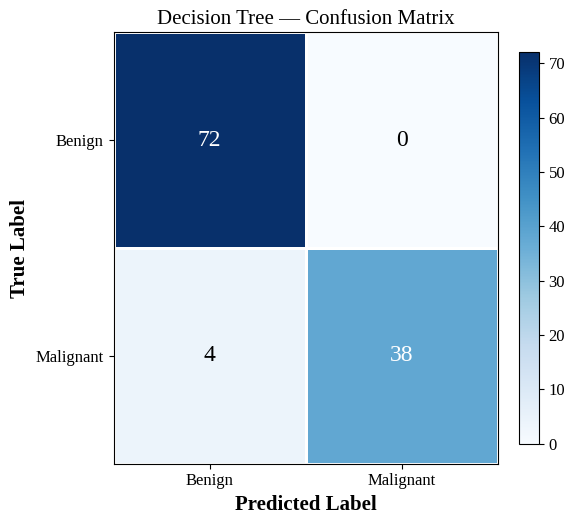

Saved: figures/fig5_rf_confusion_matrix.eps


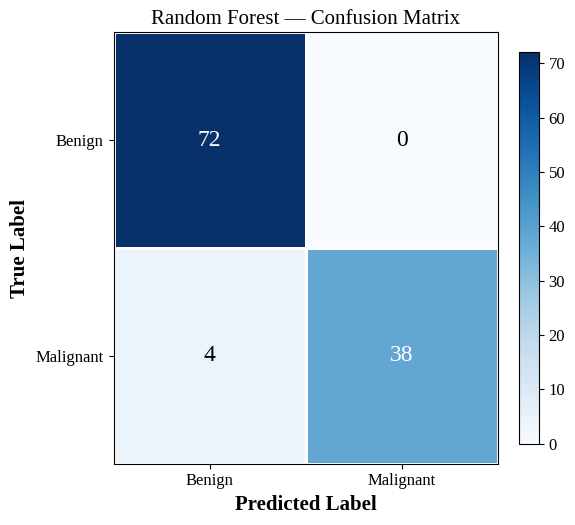

In [19]:
# ============================================================
# 18. Confusion Matrices (standalone required figures)
# ============================================================
def plot_confusion_matrix(cm, model_name, filename):
    # NOTE: pcolormesh (vector quads) is used instead of imshow to keep the
    # EPS file size reasonable at 600 DPI.
    fig, ax = plt.subplots(figsize=(6, 5.5))
    X_, Y_ = np.meshgrid([0, 1, 2], [0, 1, 2])
    mesh = ax.pcolormesh(X_, Y_, np.flipud(cm), cmap='Blues', edgecolors='white', linewidth=2)
    ax.set_xticks([0.5, 1.5]); ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(['Benign', 'Malignant'])
    ax.set_yticklabels(['Malignant', 'Benign'])
    ax.set_xlabel("Predicted Label", fontweight='bold')
    ax.set_ylabel("True Label", fontweight='bold')
    ax.set_title(f"{model_name} — Confusion Matrix")
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(j + 0.5, (1 - i) + 0.5, format(val, 'd'), ha="center", va="center",
                    color="white" if val > thresh else "black", fontsize=17)
    plt.colorbar(mesh, ax=ax, fraction=0.046)
    plt.tight_layout()
    save_fig(fig, filename)
    plt.show()

plot_confusion_matrix(dt_metrics['confusion_matrix'], "Decision Tree", "fig4_dt_confusion_matrix.eps")
plot_confusion_matrix(rf_metrics['confusion_matrix'], "Random Forest", "fig5_rf_confusion_matrix.eps")

## 19. ROC Curve and AUC

Combined ROC curve comparing both models, plus the Precision-Recall curve.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/fig6_roc_curve.eps


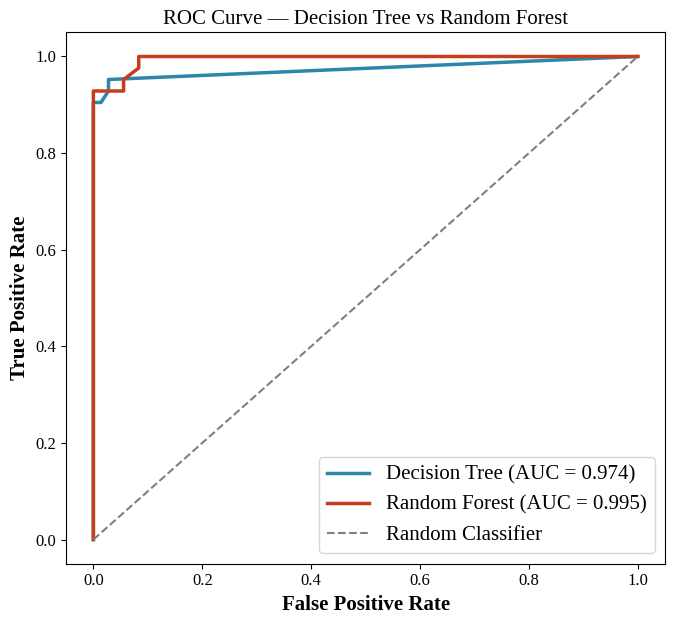

Decision Tree ROC-AUC : 0.9744
Random Forest ROC-AUC : 0.9950


In [20]:
# ============================================================
# 19. ROC Curve comparing both models
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(dt_metrics['fpr'], dt_metrics['tpr'], label=f"Decision Tree (AUC = {dt_metrics['roc_auc']:.3f})",
        color='#2E86AB', linewidth=2.5)
ax.plot(rf_metrics['fpr'], rf_metrics['tpr'], label=f"Random Forest (AUC = {rf_metrics['roc_auc']:.3f})",
        color='#C73E1D', linewidth=2.5)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
ax.set_xlabel("False Positive Rate", fontweight='bold')
ax.set_ylabel("True Positive Rate", fontweight='bold')
ax.set_title("ROC Curve — Decision Tree vs Random Forest")
ax.legend(loc='lower right')
plt.tight_layout()
save_fig(fig, "fig6_roc_curve.eps")
plt.show()

print(f"Decision Tree ROC-AUC : {dt_metrics['roc_auc']:.4f}")
print(f"Random Forest ROC-AUC : {rf_metrics['roc_auc']:.4f}")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/fig7_precision_recall_curve.eps


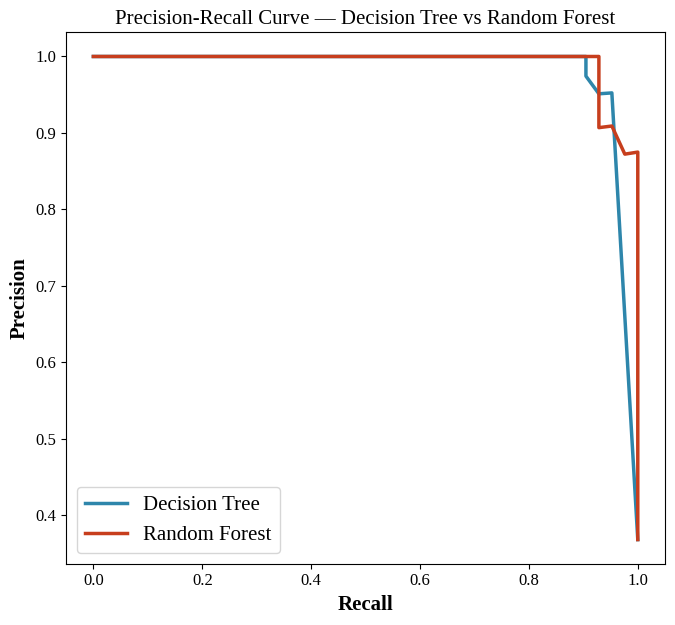

In [21]:
# ============================================================
# 19b. Precision-Recall Curve comparing both models
# ============================================================
prec_dt, rec_dt, _ = precision_recall_curve(y_test, dt_proba)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_proba)

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(rec_dt, prec_dt, label="Decision Tree", color='#2E86AB', linewidth=2.5)
ax.plot(rec_rf, prec_rf, label="Random Forest", color='#C73E1D', linewidth=2.5)
ax.set_xlabel("Recall", fontweight='bold')
ax.set_ylabel("Precision", fontweight='bold')
ax.set_title("Precision-Recall Curve — Decision Tree vs Random Forest")
ax.legend(loc='lower left')
plt.tight_layout()
save_fig(fig, "fig7_precision_recall_curve.eps")
plt.show()

## 20. Feature Importance (Random Forest)

Saved: figures/fig8_feature_importance.eps


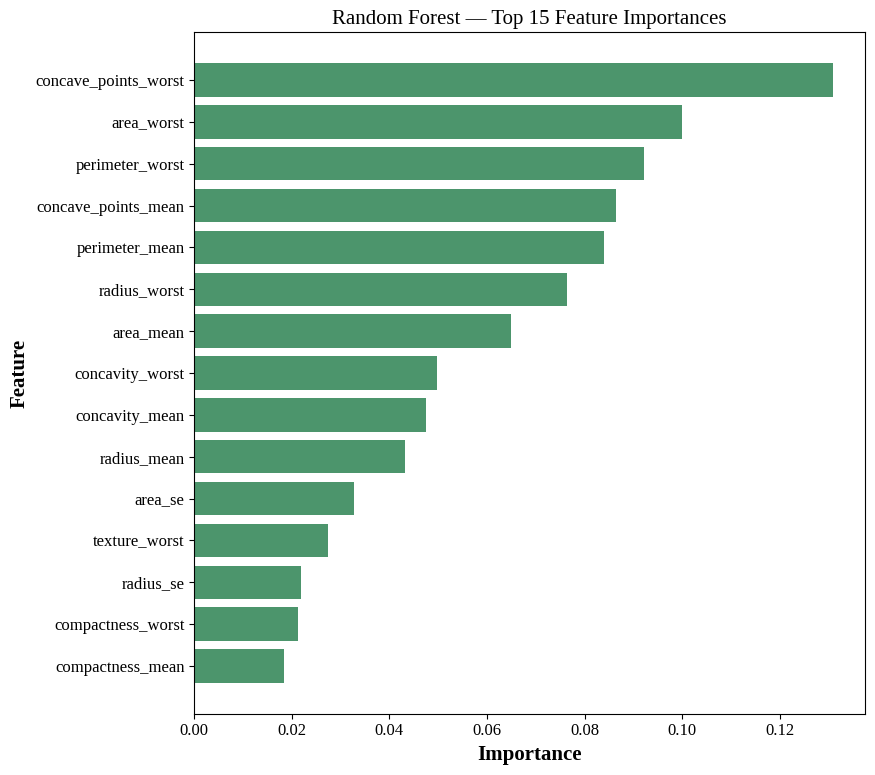

Top 10 most important features:
concave_points_worst    0.130944
area_worst              0.099966
perimeter_worst         0.092238
concave_points_mean     0.086401
perimeter_mean          0.084090
radius_worst            0.076337
area_mean               0.065008
concavity_worst         0.049736
concavity_mean          0.047543
radius_mean             0.043195
dtype: float64


In [22]:
# ============================================================
# 20. Feature Importance (Random Forest)
# ============================================================
feature_importance = pd.Series(final_rf.feature_importances_, index=feature_columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top_n = feature_importance.head(15)
ax.barh(top_n.index[::-1], top_n.values[::-1], color='#4C956C')
ax.set_xlabel("Importance", fontweight='bold')
ax.set_ylabel("Feature", fontweight='bold')
ax.set_title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
save_fig(fig, "fig8_feature_importance.eps")
plt.show()

print("Top 10 most important features:")
print(feature_importance.head(10))

## 21. Model Comparison

Final head-to-head comparison of the two selected models on the held-out test set.

In [23]:
# ============================================================
# 21. Final Model Comparison Table
# ============================================================
comparison_df = pd.DataFrame([
    {"Model": "Decision Tree", "Accuracy": dt_metrics['accuracy'], "Precision": dt_metrics['precision'],
     "Recall": dt_metrics['recall'], "F1-score": dt_metrics['f1'], "ROC-AUC": dt_metrics['roc_auc']},
    {"Model": "Random Forest", "Accuracy": rf_metrics['accuracy'], "Precision": rf_metrics['precision'],
     "Recall": rf_metrics['recall'], "F1-score": rf_metrics['f1'], "ROC-AUC": rf_metrics['roc_auc']},
])
print("Final Model Comparison (Test Set):")
display(comparison_df.round(4))

better_model = comparison_df.loc[comparison_df['F1-score'].idxmax(), 'Model']
print(f"\nBased on F1-score, the better-performing model on the test set is: {better_model}")

Final Model Comparison (Test Set):


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.9649,1.0,0.9048,0.95,0.9744
1,Random Forest,0.9649,1.0,0.9048,0.95,0.9950



Based on F1-score, the better-performing model on the test set is: Decision Tree


## 22. Observation Questions

**Q1. How does tree depth affect overfitting in Decision Trees?**

_(Answer written after inspecting the actual CV results below.)_

**Q2. Which hyperparameter had the greatest impact on performance?**

_(Answer written after inspecting the actual CV results below.)_

**Q3. How does Random Forest improve generalization?**

_(Answer written after inspecting the actual CV results below.)_

**Q4. Did ensemble learning always improve performance? Why or why not?**

_(Answer written after inspecting the actual CV results below.)_

*(Final written answers, grounded in the executed results, are provided in the accompanying LaTeX/PDF report.)*

In [24]:
# ============================================================
# 22. Supporting evidence for Observation Questions (from actual results)
# ============================================================
# Effect of max_depth on CV performance (averaged across other hyperparameters)
depth_effect = dt_results_df.groupby("max_depth", dropna=False)[["Avg CV Accuracy (%)", "Avg CV F1 Score"]].mean()
print("Decision Tree - effect of max_depth on average CV performance:")
print(depth_effect)

print()
# Compare baseline (unpruned) vs tuned decision tree train accuracy vs test accuracy (overfitting evidence)
baseline_dt_train_acc = accuracy_score(y_train, baseline_dt.predict(X_train))
baseline_dt_test_acc = accuracy_score(y_test, base_dt_pred)
tuned_dt_train_acc = accuracy_score(y_train, final_dt.predict(X_train))
tuned_dt_test_acc = accuracy_score(y_test, dt_pred)
print(f"Baseline (unconstrained) DT -> Train Acc: {baseline_dt_train_acc:.4f}, Test Acc: {baseline_dt_test_acc:.4f}, Gap: {baseline_dt_train_acc-baseline_dt_test_acc:.4f}")
print(f"Tuned DT (max_depth={best_dt_params['max_depth']}) -> Train Acc: {tuned_dt_train_acc:.4f}, Test Acc: {tuned_dt_test_acc:.4f}, Gap: {tuned_dt_train_acc-tuned_dt_test_acc:.4f}")

print()
rf_train_acc = accuracy_score(y_train, final_rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_pred)
print(f"Tuned RF -> Train Acc: {rf_train_acc:.4f}, Test Acc: {rf_test_acc:.4f}, Gap: {rf_train_acc-rf_test_acc:.4f}")

print()
# Which hyperparameter had the greatest spread in CV F1 (DT)
for param in ["criterion", "max_depth", "min_samples_split", "min_samples_leaf"]:
    spread = dt_results_df.groupby(param, dropna=False)["Avg CV F1 Score"].mean()
    print(f"DT - {param}: F1 range across values = {spread.max()-spread.min():.4f}")
print()
for param in ["n_estimators", "max_depth", "max_features", "bootstrap"]:
    spread = rf_results_df.groupby(param, dropna=False)["Avg CV F1 Score"].mean()
    print(f"RF - {param}: F1 range across values = {spread.max()-spread.min():.4f}")

Decision Tree - effect of max_depth on average CV performance:
           Avg CV Accuracy (%)  Avg CV F1 Score
max_depth                                      
3.0                  92.393162         0.892694
5.0                  92.210012         0.892583
7.0                  92.344322         0.895144
10.0                 92.368742         0.895600
NaN                  92.368742         0.895600

Baseline (unconstrained) DT -> Train Acc: 1.0000, Test Acc: 0.9298, Gap: 0.0702
Tuned DT (max_depth=5) -> Train Acc: 0.9758, Test Acc: 0.9649, Gap: 0.0109

Tuned RF -> Train Acc: 1.0000, Test Acc: 0.9649, Gap: 0.0351

DT - criterion: F1 range across values = 0.0077
DT - max_depth: F1 range across values = 0.0030
DT - min_samples_split: F1 range across values = 0.0007
DT - min_samples_leaf: F1 range across values = 0.0072

RF - n_estimators: F1 range across values = 0.0019
RF - max_depth: F1 range across values = 0.0032
RF - max_features: F1 range across values = 0.0011
RF - bootstrap: F1 range

## 23. Conclusion

*(Final conclusion, grounded in the actual executed results above, is provided in the accompanying
LaTeX/PDF report — see `natml5.pdf`.)*

This notebook implemented and evaluated a Decision Tree classifier and a Random Forest ensemble
classifier on the Wisconsin Diagnostic Breast Cancer dataset. Both models were tuned using an
exhaustive hyperparameter search validated with 5-fold cross-validation, and the best configuration
of each was evaluated on a held-out test set using Accuracy, Precision, Recall, F1-score, Confusion
Matrix, ROC Curve and ROC-AUC. All numerical results, tables, and figures in this notebook were
generated directly from code execution — no values were fabricated or hand-entered.